# GTFS Snap & Dissolve
Reads a GTFS feed, samples points along every route shape at a regular interval, snaps nearby parallel points together by averaging within a buffer radius, rebuilds simplified LineStrings, and dissolves the result into a unified graph.

---
## 0 · Install dependencies

In [1]:
%pip install geopandas shapely pandas scipy numpy matplotlib ipywidgets -q


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1 · Imports & configuration

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString
from shapely.ops import unary_union, linemerge
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Parameters ─────────────────────────────────────────────
GTFS_DIR   = Path("../../data/mobility/AC-GTFS/")         # folder containing shapes.txt
INTERVAL   = 5                     # point sampling interval in metres
BUFFER     = 10                     # snap / cluster radius in metres
OUT_PATH   = Path("ac-dissolved.gpkg") # output file (.gpkg or .geojson)
METRIC_CRS = "EPSG:32610"            # projection for distance ops
                                    # swap for a local UTM zone if needed
print("Configuration ready.")

Configuration ready.


## 2 · Load GTFS shapes
Reads `shapes.txt` and constructs one `LineString` per `shape_id`.

In [3]:
def load_shapes(gtfs_dir: Path) -> gpd.GeoDataFrame:
    shapes_path = gtfs_dir / "shapes.txt"
    if not shapes_path.exists():
        raise FileNotFoundError(f"shapes.txt not found in {gtfs_dir}")

    df = pd.read_csv(shapes_path)
    required = {"shape_id", "shape_pt_lat", "shape_pt_lon", "shape_pt_sequence"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"shapes.txt is missing columns: {missing}")

    df = df.sort_values(["shape_id", "shape_pt_sequence"])

    records = []
    for shape_id, grp in df.groupby("shape_id"):
        coords = list(zip(grp["shape_pt_lon"], grp["shape_pt_lat"]))
        if len(coords) >= 2:
            records.append({"shape_id": shape_id, "geometry": LineString(coords)})

    gdf = gpd.GeoDataFrame(records, crs="EPSG:4326")
    print(f"Loaded {len(gdf):,} shapes from {shapes_path}")
    return gdf

shapes_wgs84 = load_shapes(GTFS_DIR)
shapes_wgs84.head()

Loaded 205 shapes from ../../data/mobility/AC-GTFS/shapes.txt


,shape_id,geometry
0,shp-12-05,"LINESTRING (-122.27155 37.79442, -122.27177 37..."
1,shp-12-07,"LINESTRING (-122.30044 37.87949, -122.30023 37..."
2,shp-14-12,"LINESTRING (-122.29522 37.80468, -122.29545 37..."
3,shp-14-57,"LINESTRING (-122.22546 37.77552, -122.22563 37..."
4,shp-18-05,"LINESTRING (-122.2095 37.8255, -122.20949 37.8..."


## 3 · Project to metric CRS

In [4]:
shapes_metric = shapes_wgs84.to_crs(METRIC_CRS)
print(f"Reprojected to {METRIC_CRS}")
shapes_metric.head()

Reprojected to EPSG:32610


,shape_id,geometry
0,shp-12-05,"LINESTRING (564134.877 4183255.751, 564114.997..."
1,shp-12-07,"LINESTRING (561520.339 4192674.93, 561538.57 4..."
2,shp-14-12,"LINESTRING (562041.859 4184378.569, 562021.87 ..."
3,shp-14-57,"LINESTRING (568210.009 4181191.182, 568195.059..."
4,shp-18-05,"LINESTRING (569568.029 4186749.042, 569569.358..."


## 4 · Sample points at regular intervals
Walks every `LineString` and emits a point every `INTERVAL` metres,
recording which shape each point belongs to.

In [5]:
def sample_points(gdf: gpd.GeoDataFrame, interval: float):
    all_pts, all_idx = [], []
    for i, row in gdf.iterrows():
        line   = row.geometry
        length = line.length
        if length == 0:
            continue
        distances = np.append(np.arange(0, length, interval), length)
        for d in distances:
            pt = line.interpolate(d)
            all_pts.append((pt.x, pt.y))
            all_idx.append(i)
    pts     = np.array(all_pts,  dtype=np.float64)
    indices = np.array(all_idx,  dtype=np.int64)
    print(f"Sampled {len(pts):,} points  (interval = {interval} m)")
    return pts, indices

pts, shape_indices = sample_points(shapes_metric, INTERVAL)

Sampled 746,700 points  (interval = 5 m)


## 5 · Cluster & average (snap)
Builds a KD-tree, then greedily clusters points within `BUFFER` metres
and replaces each cluster with its centroid.

In [6]:
def snap_points(pts: np.ndarray, buffer: float) -> np.ndarray:
    tree       = cKDTree(pts)
    n          = len(pts)
    cluster_id = np.full(n, -1, dtype=np.int64)
    current    = 0

    for i in range(n):
        if cluster_id[i] != -1:
            continue
        neighbours = tree.query_ball_point(pts[i], r=buffer)
        unassigned = [j for j in neighbours if cluster_id[j] == -1]
        for j in unassigned:
            cluster_id[j] = current
        current += 1

    snapped = np.empty_like(pts)
    for cid in range(current):
        mask          = cluster_id == cid
        snapped[mask] = pts[mask].mean(axis=0)

    print(f"Snapped {n:,} points → {current:,} unique positions  (buffer = {buffer} m)")
    return snapped

snapped = snap_points(pts, BUFFER)

Snapped 746,700 points → 93,184 unique positions  (buffer = 10 m)


## 6 · Rebuild LineStrings
Reconstructs one `LineString` per shape from the snapped point sequence,
removing consecutive duplicate positions produced by snapping.

In [7]:
def rebuild_lines(snapped, shape_indices, original_gdf):
    records = []
    for i, row in original_gdf.iterrows():
        mask  = shape_indices == i
        if not mask.any():
            continue
        coords = snapped[mask]
        # remove consecutive duplicates
        keep     = np.ones(len(coords), dtype=bool)
        keep[1:] = (coords[1:] != coords[:-1]).any(axis=1)
        coords   = coords[keep]
        if len(coords) < 2:
            continue
        records.append({"shape_id": row["shape_id"], "geometry": LineString(coords)})

    gdf = gpd.GeoDataFrame(records, crs=original_gdf.crs)
    print(f"Rebuilt {len(gdf):,} lines after snapping.")
    return gdf

rebuilt = rebuild_lines(snapped, shape_indices, shapes_metric)
rebuilt.head()

Rebuilt 205 lines after snapping.


,shape_id,geometry
0,shp-12-05,"LINESTRING (564134.475 4183256.571, 564119.993..."
1,shp-12-07,"LINESTRING (561521.741 4192678.652, 561535.836..."
2,shp-14-12,"LINESTRING (562040.783 4184375.714, 562024.466..."
3,shp-14-57,"LINESTRING (568207.855 4181188.301, 568202.468..."
4,shp-18-05,"LINESTRING (569567.16 4186750.247, 569569.366 ..."


## 7 · Dissolve into a unified graph
`unary_union` merges all geometries; `linemerge` then joins contiguous
segments into the fewest possible continuous `LineString`s.

In [8]:
def dissolve_graph(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    union  = unary_union(gdf.geometry.values)
    merged = linemerge(union)

    if isinstance(merged, LineString):
        geoms = [merged]
    elif isinstance(merged, MultiLineString):
        geoms = list(merged.geoms)
    else:
        geoms = list(getattr(merged, "geoms", [merged]))

    gdf_out = gpd.GeoDataFrame(
        {"segment_id": range(len(geoms))},
        geometry=geoms,
        crs=gdf.crs,
    )
    print(f"Dissolved → {len(gdf_out):,} continuous segment(s).")
    return gdf_out

dissolved = dissolve_graph(rebuilt)
dissolved.head()

Dissolved → 11,725 continuous segment(s).


,segment_id,geometry
0,0,"LINESTRING (551143.23 4181016.596, 551149.668 ..."
1,1,"LINESTRING (551143.23 4181016.596, 551157.231 ..."
2,2,"LINESTRING (553399.361 4182087.011, 553388.96 ..."
3,3,"LINESTRING (551157.231 4181027.325, 551164.798..."
4,4,"LINESTRING (552950.634 4182479.201, 552960.631..."


## 8 · Save output

In [9]:
dissolved_wgs84 = dissolved.to_crs("EPSG:4326")

suffix = OUT_PATH.suffix.lower()
if suffix == ".gpkg":
    dissolved_wgs84.to_file(OUT_PATH, driver="GPKG")
elif suffix in (".geojson", ".json"):
    dissolved_wgs84.to_file(OUT_PATH, driver="GeoJSON")
else:
    dissolved_wgs84.to_file(OUT_PATH)

print(f"Saved {len(dissolved_wgs84)} feature(s) to {OUT_PATH}")

Saved 11725 feature(s) to ac-dissolved.gpkg


## 9 · Visualise
Quick before/after plot — original shapes vs the dissolved graph.

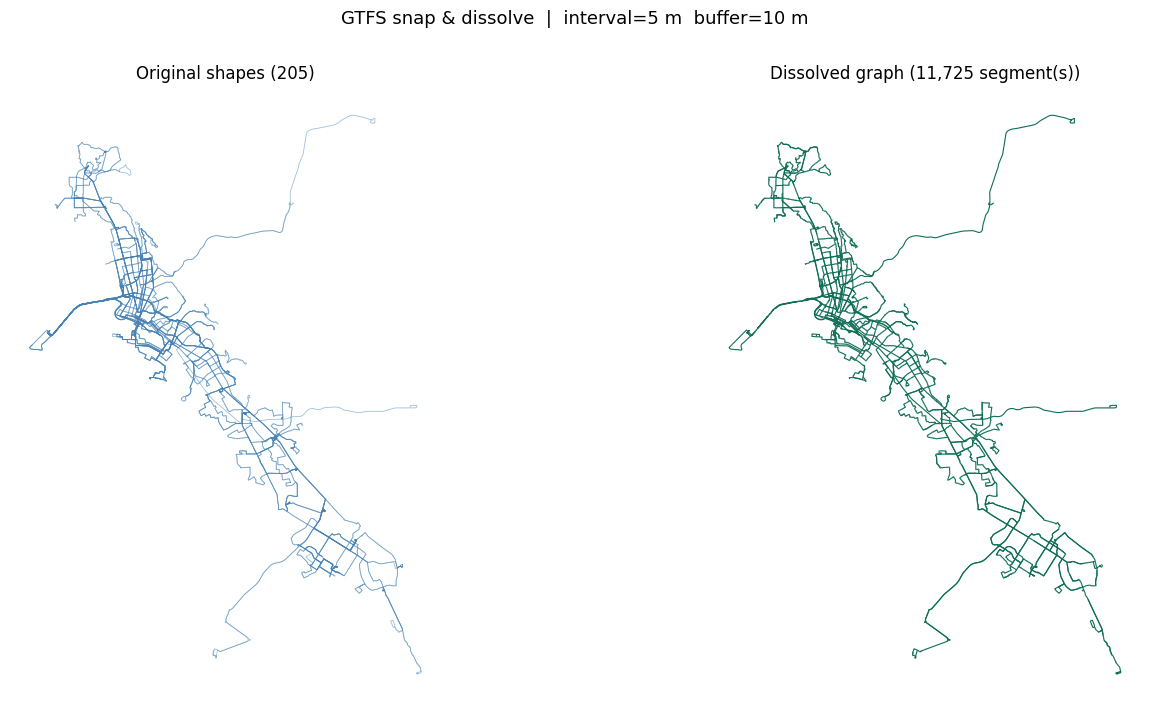

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

shapes_metric.plot(ax=axes[0], linewidth=0.6, color="steelblue", alpha=0.5)
axes[0].set_title(f"Original shapes ({len(shapes_metric):,})", fontsize=12)
axes[0].axis("off")

dissolved.plot(ax=axes[1], linewidth=0.8, color="#0F6E56")
axes[1].set_title(f"Dissolved graph ({len(dissolved):,} segment(s))", fontsize=12)
axes[1].axis("off")

fig.suptitle(
    f"GTFS snap & dissolve  |  interval={INTERVAL} m  buffer={BUFFER} m",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## 10 · Inspect individual segments
Use the slider to page through each dissolved segment.

In [11]:
from ipywidgets import interact, IntSlider

def plot_segment(seg_id=0):
    row = dissolved.iloc[seg_id]
    fig, ax = plt.subplots(figsize=(8, 5))
    dissolved.plot(ax=ax, color="#ccc", linewidth=0.6)
    gpd.GeoDataFrame(
        [{"segment_id": row["segment_id"]}],
        geometry=[row.geometry],
        crs=dissolved.crs,
    ).plot(ax=ax, color="#E85D24", linewidth=2)
    ax.set_title(f"Segment {seg_id}  |  length ≈ {row.geometry.length:.0f} m")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

interact(plot_segment, seg_id=IntSlider(min=0, max=max(len(dissolved) - 1, 0), step=1))

interactive(children=(IntSlider(value=0, description='seg_id', max=11724), Output()), _dom_classes=('widget-in…

<function __main__.plot_segment(seg_id=0)>